# Basic Computer Vision

In [1]:
import cv2
import numpy as np

In [2]:
cv2.__version__

'4.12.0'

## < Getting Started with Images >

### (1) Read Image

#### cv2.imread(filename, flag)

- flag = cv2.IMREAD_COLOR : Loads a color image. (1) 
- flag = cv2.IMREAD_GRAYSCALE : Loads image in grayscale mode (0)
    

In [4]:
# img = cv2.imread("./data/opencv-4.1-feature-image.png", cv2.IMREAD_COLOR)
img = cv2.imread("./data/opencv-4.1-feature-image.png")

### (2) Display Image

#### Using OpenCV

- cv2.imshow(window title, array) # Display an image in a window

- cv2.waitKey(delay) #Waits for specified milliseconds for any keyboard event

- cv2.destroyAllWindows() #Destroys all the windows created

In [ ]:
cv2.imshow('image', img)
k = cv2.waitKey(0)
if k == 27:         # wait for ESC key to exit
    cv2.destroyAllWindows()

#### Using Matplotlib
- Matplotlib is a plotting library for Python which gives you wide variety of plotting methods.

- cv2.cvtColor(img, flag) #Convert Color space BGR to RGB

- plt.imshow(ung) #Display an image in a jupyter notebook cell

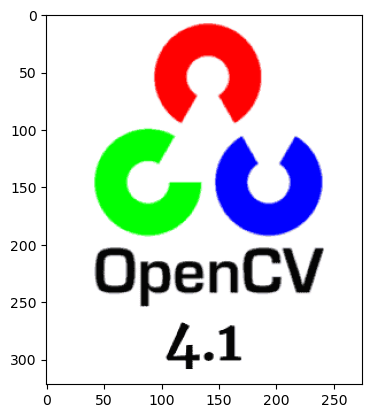

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

cvt_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(cvt_img)
# plt.imshow(img)
# plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

### Check Image Data information

- img.shape #print image dimension
- img.size # The number of all elements image array
- img.dtype # Data type of image array
- img[y,x] # Pixel value of image (y,x)

In [8]:
print(cvt_img.shape)
print(cvt_img.size)
print(cvt_img.dtype)
print(cvt_img[50,50]) # [R G B] ex)[255 255 255] = white 

(322, 275, 3)
265650
uint8
[255 255 255]


In [9]:
#to do
red_pixel = cvt_img[50,100]
green_pixel = cvt_img[150,60]
blue_pixel = cvt_img[150,170]
white_pixel = cvt_img[10,10] 
black_pixel = cvt_img[220,75]


print("red pixel :", red_pixel)
print("green pixel :", green_pixel)
print("blue pixel :", blue_pixel)
print("white pixel :", white_pixel)
print("black pixel :", black_pixel)

red pixel : [255   1   1]
green pixel : [  1 255   1]
blue pixel : [  1   1 255]
white pixel : [255 255 255]
black pixel : [5 5 5]


### (3) Drawing Function

Drawing Functions have some common arguments as given below:

- img : The image where you want to draw the shapes
- color : Color of the shape. For grayscale, just pass the scalar value.
- thickness : Thickness of the line or circle etc.
- lineType : Type of line

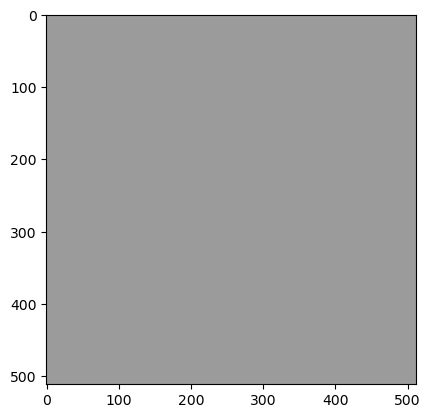

In [10]:
# np.full(shape, fill_value, dtype)
# 512 x 512 pixel, 3 channels (RGB)
drawing_img = np.full((512, 512, 3), 255, np.uint8)
# drawing_img = np.zeros((512, 512, 3), np.uint8)
drawing_img -= 100

plt.imshow(drawing_img)

#### cv2.line(img, start, end, color, thickness)

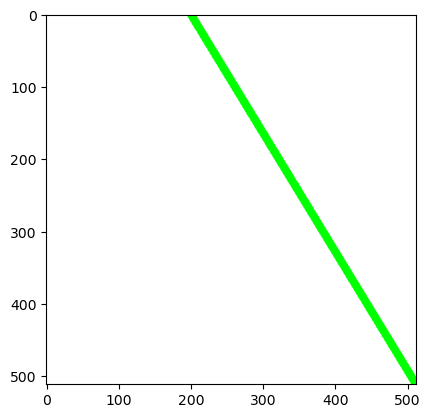

In [11]:
drawing_img = np.full((512, 512, 3), 255, np.uint8)
cv2.line(drawing_img, (200, 0), (511, 511), (0, 255, 0), 10) # (x,y) coordinates
plt.imshow(drawing_img)

#### cv2.rectangle(img, start, end, color, thickness)

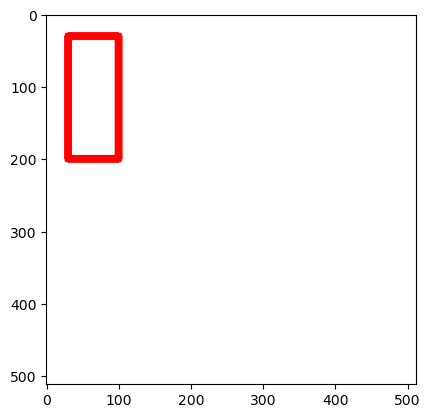

In [12]:
drawing_img = np.full((512, 512, 3), 255, np.uint8)
cv2.rectangle(drawing_img, (30, 30), (100, 200), (255, 0, 0), 10) # (x,y) coordinates
plt.imshow(drawing_img)

#### cv2.circle(img, center, radian, color, thickness)

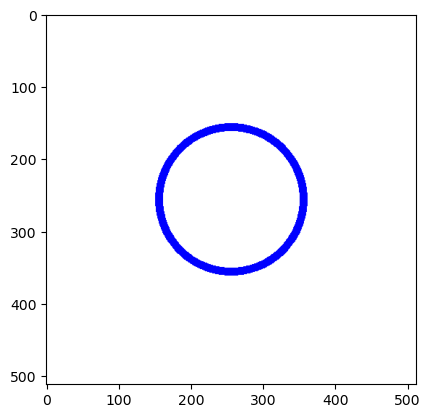

In [13]:
drawing_img = np.full((512, 512, 3), 255, np.uint8)
cv2.circle(drawing_img, (256, 256), 100, (0, 0, 255), 10)
plt.imshow(drawing_img)

#### cv2.putText(img, text, org, font, fontSacle, color, thickness)

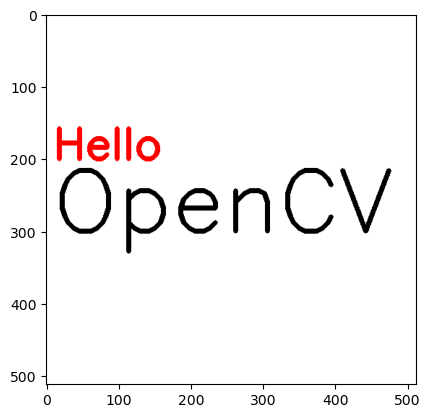

In [14]:
drawing_img = np.full((512, 512, 3), 255, np.uint8)
cv2.putText(drawing_img, 'Hello', (10,200), cv2.FONT_HERSHEY_SIMPLEX, 2, (255,0,0),5)
cv2.putText(drawing_img, 'OpenCV', (10,300), cv2.FONT_HERSHEY_SIMPLEX, 4, (0,0,0),5)
plt.imshow(drawing_img)

### (4) Editing Image

#### cv2.cvtColor(img, flag)
convert an image to other color space
- flag = cv2.COLOR_RGB2BGR : RGB -> BGR
- flag = cv2.COLOR_BGR2GRAY : BGR -> Grayscale
- flag = cv2.COLOR_BGR2HSV : BGR -> HSV

#### cv2.resize(img, dsize, fx, fy, interpolation)
resize image
- dsize : Manual Size ex) (100,200)
- fx : multiple of horizontal size
- fy : multiple of vertical size
- interpolation : 보간법  ex) cv2.INTER_AREA, cv2.INTER_CUBIC

#### cv2.flip(img, flag)
flip image
- flag = 1 : 좌우
- flag = 0 : 상하
- flag = -1 : 상하좌우

#### cv2.rotate(img, flag)
rotate image
- flag = cv2.ROTATE_90_CLOCKWISE / cv2.ROTATE_90_COUNTERCLOCKWISE / cv2.ROTATE_180
- 90도가 아닌 회전을 원하는 경우 cv2.warpAffine 참조

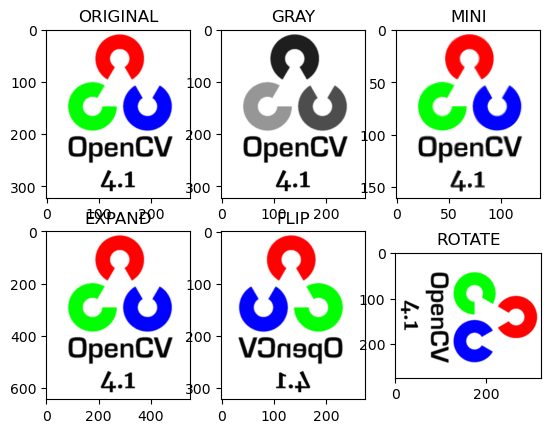

In [15]:
cvt_img2 = cv2.cvtColor(cvt_img, cv2.COLOR_BGR2GRAY)    # only 1 channel left
cvt_img2 = cv2.cvtColor(cvt_img2, cv2.COLOR_GRAY2BGR)   # recover 3 channels
mini_img = cv2.resize(cvt_img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
expand_img = cv2.resize(cvt_img, (2*cvt_img.shape[1], 2*cvt_img.shape[0]), interpolation = cv2.INTER_CUBIC)
flip_img = cv2.flip(cvt_img, 1)
rotate_img = cv2.rotate(cvt_img, cv2.ROTATE_90_CLOCKWISE)

titles = ["ORIGINAL", "GRAY", "MINI", "EXPAND", "FLIP", "ROTATE"]
imgs = [cvt_img, cvt_img2, mini_img, expand_img, flip_img, rotate_img]

for i in range(6):
    plt.subplot(2,3, i+1)
    plt.imshow(imgs[i])
    plt.title(titles[i])

### (5) Save Image 

#### cv2.imwrite(filename, image)
Use the function cv.imwrite() to save an image

In [16]:
drawing_img = cv2.cvtColor(drawing_img, cv2.COLOR_RGB2BGR)  # BGR in OpenCV
cv2.imwrite('HelloOpenCV.jpg', drawing_img)

True

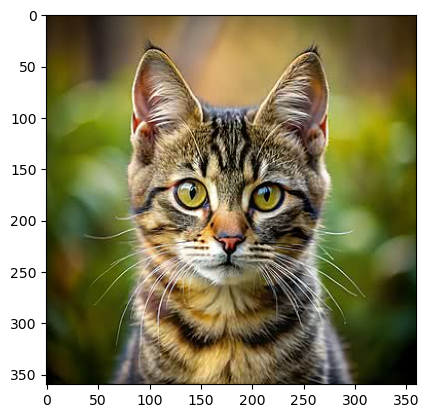

In [17]:
# cv2.imread(filenames, flags)
# flag = 1 : BGR color
cat_img_color = cv2.imread('./data/cat.jpg', 1)
cat_img_color = cv2.cvtColor(cat_img_color, cv2.COLOR_BGR2RGB)  # matplotlib based on RGB
plt.imshow(cat_img_color)

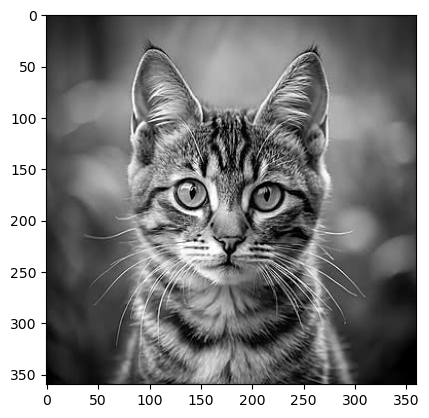

In [18]:
gray_img = cv2.imread("data/cat.jpg", 0) # flag 0 : grayscale
gray_img = cv2.cvtColor(gray_img, cv2.COLOR_BGR2RGB) # ?
plt.imshow(gray_img)

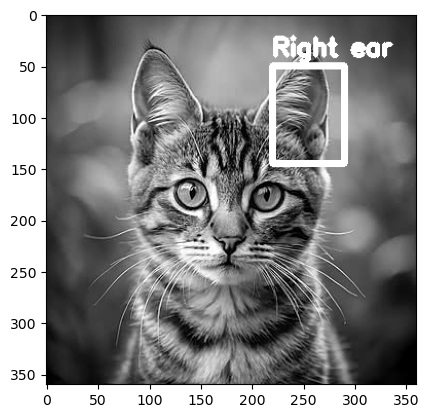

In [19]:
# <to do> - convert image to grayscale/drawing rectagle at its right ear and put test "right ear"
cat_img = cv2.imread('./data/cat.jpg', 0)
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
cv2.rectangle(cat_img, (220, 50), (290,145), (255,255,255), 5)
cv2.putText(cat_img, 'Right ear', (220, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 3)
plt.imshow(cat_img)

## < Getting Started with Videos >

#### cv2.VideoCaputer(filename or device index)
Create a VideoCapture object to capture a video.

Device index is just the number to specify which camera.

#### cap.get(propId) 
Access some of the features of this video

In [20]:
cap = cv2.VideoCapture("./data/Megamind.avi")
videoWidth = cap.get(cv2.CAP_PROP_FRAME_WIDTH)  # compute the number of pixels from the frame width
videoHeight = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
frameCount = cap.get(cv2.CAP_PROP_FRAME_COUNT)  # the total num of frames
fps = cap.get(cv2.CAP_PROP_FPS)

print("width :", videoWidth)
print("height :", videoHeight)
print("frame count :", frameCount)
print("fps :", fps)

width : 720.0
height : 528.0
frame count : 270.0
fps : 23.976


#### ret, img = cap.read()
read image from the video Object
- ret : whether image is readable or not (Boolean)
- img : image object

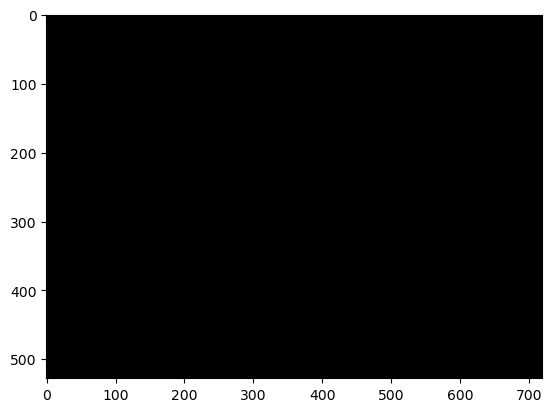

In [21]:
ret, image = cap.read() # read(): reads the next frame, sequentially
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

#### cv2.VideoWriter(outputFile, fourcc, fps, size)
Create a VideoWriter object to write a video.

- outputFile (str) – file name 
- fourcc – Codec information. cv2.VideoWriter_fourcc()
- frame (float) – the value of fps
- size (list) – size (ex; 640, 480)

In [22]:
fourcc = cv2.VideoWriter_fourcc(*'DIVX')
size = (int(videoWidth/2), int(videoHeight/2))
print(size)
out = cv2.VideoWriter('output.avi', fourcc, 24, size)

(360, 264)


#### out.write(image)
save the image into video object.

#### out.release()
Finish to save the video object.

In [23]:
while cap.isOpened():
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
        
    frame = cv2.resize(frame, size)
    frame = cv2.flip(frame, 0)
    cv2.rectangle(frame, (30, 30), (100, 100), (255, 0, 0), 5)
    out.write(frame)
    
cap.release()
out.release()

Can't receive frame (stream end?). Exiting ...


# Image Processing

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [5]:
data_path = './data/'

## < Access pixel values and modify >

(360, 360, 3)


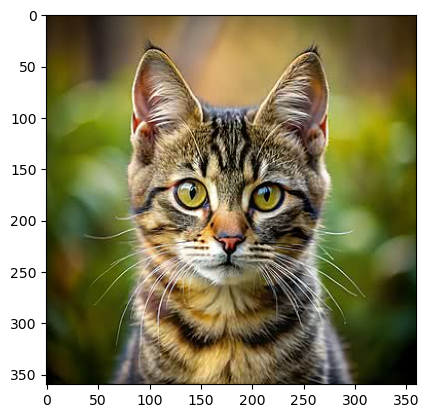

In [26]:
block_img = cv2.imread(data_path + 'cat.jpg', 1)
block_img = cv2.cvtColor(block_img, cv2.COLOR_BGR2RGB)
print(block_img.shape)
plt.imshow(block_img)

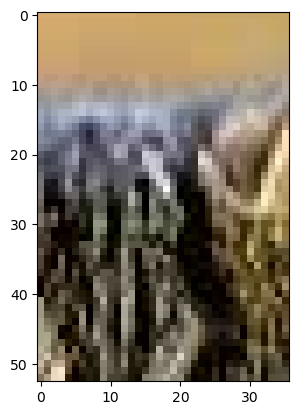

In [27]:
plt.imshow(block_img[79:132, 170:206, :])

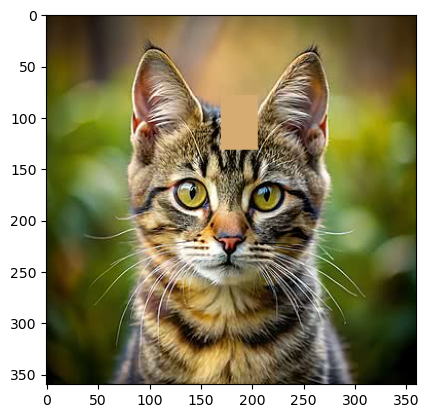

In [28]:
block_img[79:132, 170:206,:] = block_img[79,170,:]
plt.imshow(block_img)

## < Image Thresholding >

![threshold_info.png](data/threshold_info.png)

#### cv2.threshold(src, thresh, maxval, type) → retval, dst 
If pixel value is greater than a threshold value, it is assigned one value (may be white), else it is assigned another value (may be black).
 
- thresholding type
- threshold_value : 픽셀 문턱값
- Value : 픽셀 문턱값보다 클 때 적용되는 최대값

cv2.THRESH_BINARY : Threshold보다 크면 Value, 아니면 0

cv2.THRESH_BINARY_INV : Threshold보다 크면 0이고 아니면 Value

cv2.THRESH_TRUNC : Threshold보다 크면 threshold_value, 작으면 픽셀 값

cv2.THRESH_TOZERO : Threshold보다 크면 픽셀값, 작으면 0

cv2.THRESH_TOZERO_INV : Threshold보다 크면 0, 작으면 픽셀값

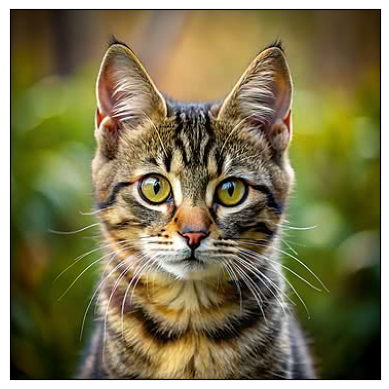

In [6]:
gradient_img = cv2.imread(data_path + "cat.jpg", 1)
gradient_img = cv2.cvtColor(gradient_img, cv2.COLOR_BGR2RGB)
plt.xticks([])
plt.yticks([])
plt.imshow(gradient_img)

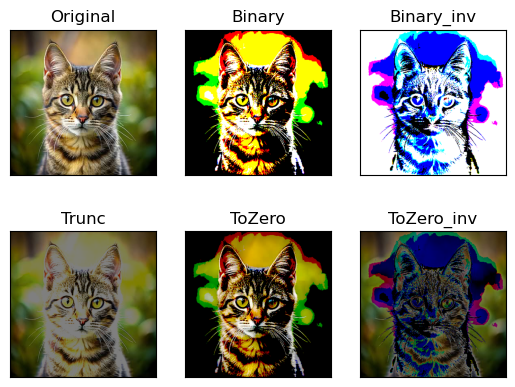

In [7]:
ret, thresh1 = cv2.threshold(gradient_img, 127, 255, cv2.THRESH_BINARY)
ret, thresh2 = cv2.threshold(gradient_img, 127, 255, cv2.THRESH_BINARY_INV)
ret, thresh3 = cv2.threshold(gradient_img, 127, 255, cv2.THRESH_TRUNC)
ret, thresh4 = cv2.threshold(gradient_img, 127, 255, cv2.THRESH_TOZERO)
ret, thresh5 = cv2.threshold(gradient_img, 127, 255, cv2.THRESH_TOZERO_INV)

titles = ["Original", "Binary", "Binary_inv", "Trunc", "ToZero", "ToZero_inv"]
imgs = [gradient_img, thresh1, thresh2, thresh3 ,thresh4, thresh5]

for i in range(6):
    plt.subplot(2,3, i+1)
    plt.imshow(imgs[i])
    plt.title(titles[i])
    plt.xticks([])
    plt.yticks([])
plt.show()

#### cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)

- Adaptive Method

cv2.ADAPTIVE_THRESH_MEAN_C

cv2.ADAPTIVE_THRESH_GAUSSIAN_C

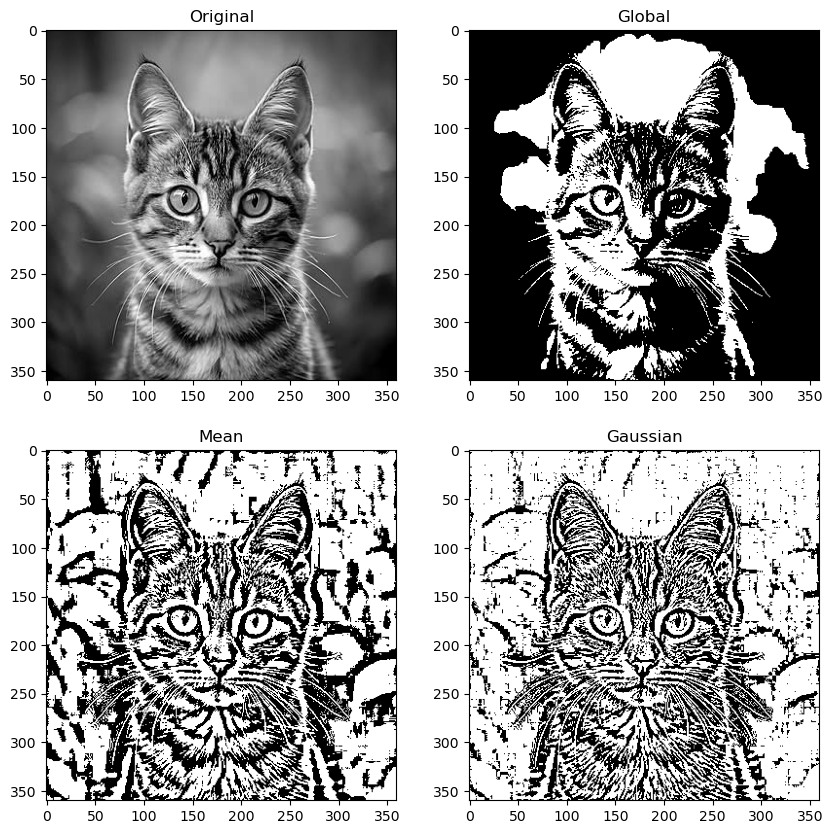

In [11]:
cat_img = cv2.imread(data_path + 'cat.jpg', 0)

ret, th1 = cv2.threshold(cat_img, 127, 255, cv2.THRESH_BINARY)

th2 = cv2.adaptiveThreshold(cat_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, 2)

th3 = cv2.adaptiveThreshold(cat_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 2)

titles = ['Original','Global','Mean','Gaussian']
images = [cat_img, th1, th2, th3]

f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(10,10))
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
th1 = cv2.cvtColor(th1, cv2.COLOR_BGR2RGB)
th2 = cv2.cvtColor(th2, cv2.COLOR_BGR2RGB)
th3 = cv2.cvtColor(th3, cv2.COLOR_BGR2RGB)
ax1.set_title('Original')
ax1.imshow(cat_img)

ax2.set_title('Global')
ax2.imshow(th1)

ax3.set_title('Mean')
ax3.imshow(th2)

ax4.set_title('Gaussian')
ax4.imshow(th3)
plt.show()

#### otsu binarization

128.0 107.0


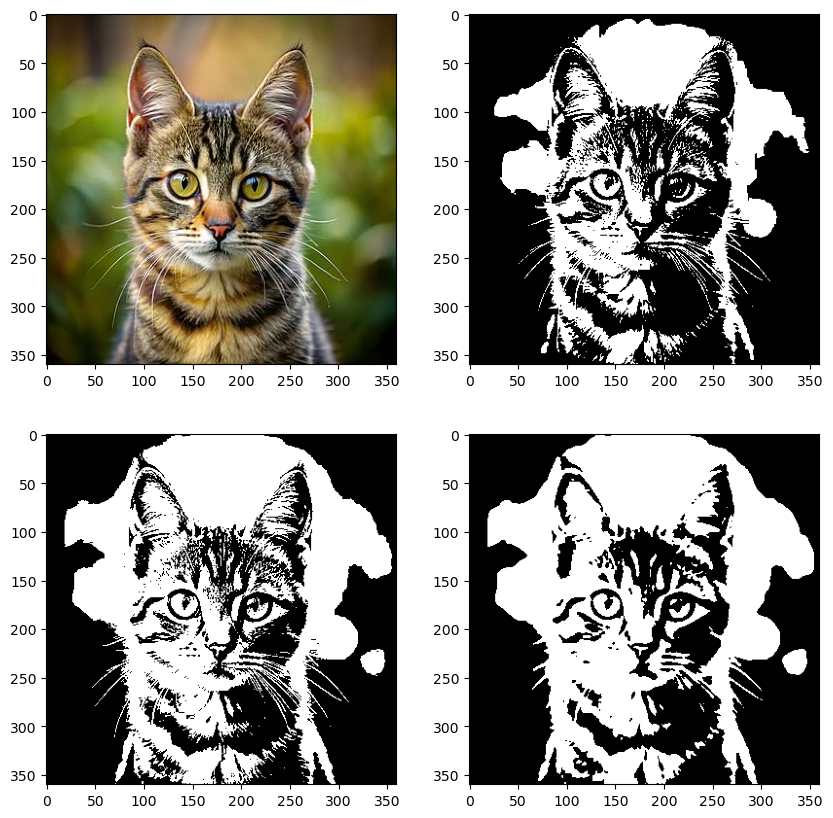

In [13]:
cat_img_c = cv2.imread(data_path+"cat.jpg", 1)

cat_img = cv2.imread(data_path+"cat.jpg", 0)

ret1, th = cv2.threshold(cat_img, 128, 255, cv2.THRESH_BINARY)

ret2, otsu1 = cv2.threshold(cat_img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

blur = cv2.GaussianBlur(cat_img, (5,5),0)
ret, otsu2 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print(ret1, ret2)

f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(10,10))

lena_img_c = cv2.cvtColor(cat_img_c, cv2.COLOR_BGR2RGB) 
th = cv2.cvtColor(th, cv2.COLOR_BGR2RGB)
otsu1 = cv2.cvtColor(otsu1, cv2.COLOR_BGR2RGB)
otsu2 = cv2.cvtColor(otsu2, cv2.COLOR_BGR2RGB)

ax1.imshow(lena_img_c)
ax2.imshow(th)
ax3.imshow(otsu1)
ax4.imshow(otsu2)
plt.show()

# Image Filtering 

## < Blurring >

#### cv2.filter2D(img, ddepth, kernel)

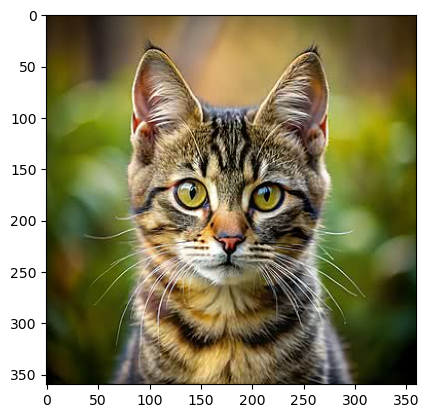

In [14]:
img = cv2.imread(data_path + "cat.jpg")
gray_img = cv2.imread(data_path + "cat.jpg", 0)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [15]:
k = np.ones((3,3), np.uint8)
k = k/(3*3)
k

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

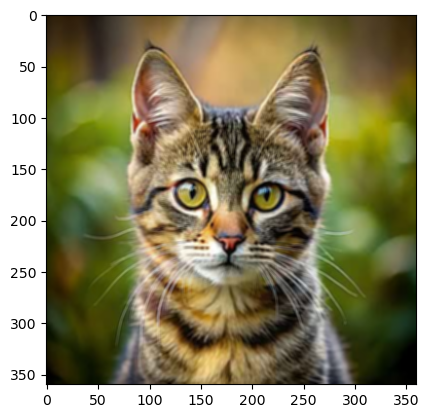

In [ ]:
blur_dst = cv2.filter2D(img, -1, k) # -1 : 입력영상과 동일한 크기의 이미지로 출력
plt.imshow(blur_dst)

#### cv2.Blur(img, ksize)
#### cv2.GaussianBlur(img, ksize, sigma)
#### cv2.medianBlur(img, ksize)

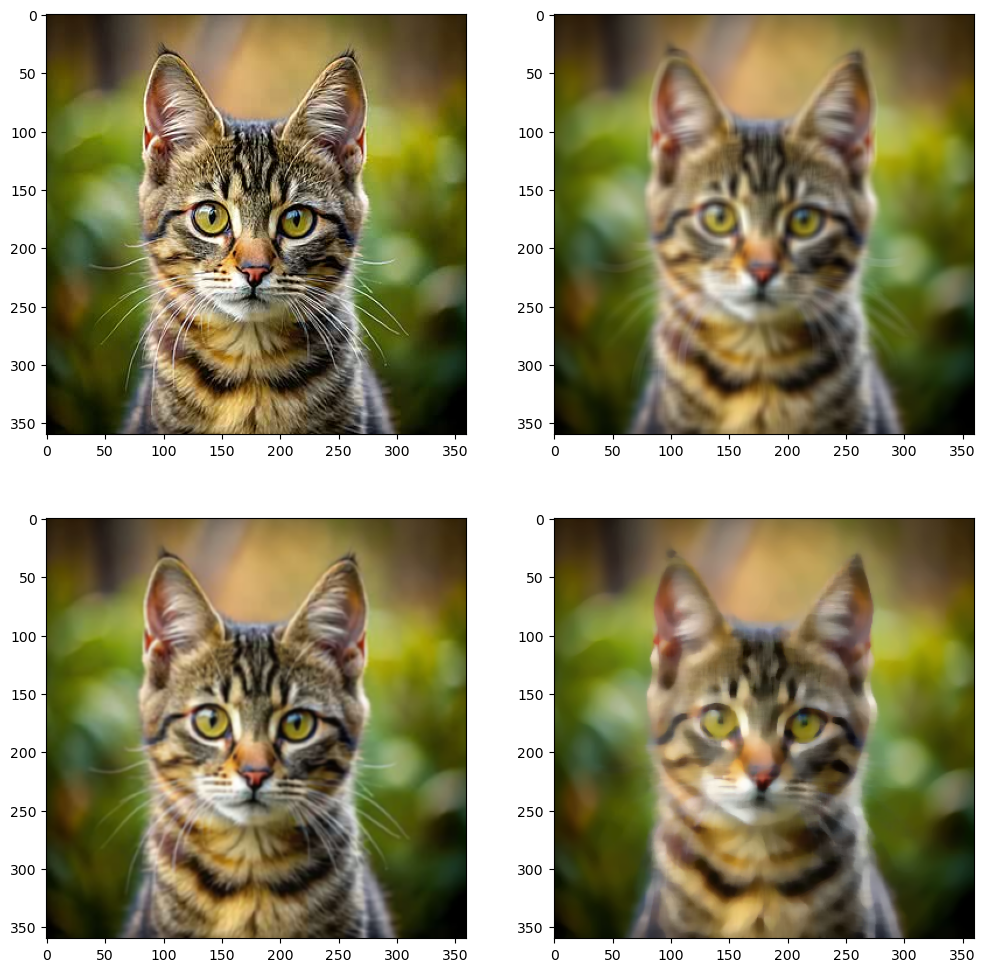

In [17]:
dst1 = cv2.blur(img,(7,7))
dst2 = cv2.GaussianBlur(img,(5,5),0)
dst3 = cv2.medianBlur(img,9)

images = [img,dst1,dst2,dst3]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize =(12,12))
axs = [ax1, ax2, ax3, ax4]

for i in range(4):
    axs[i].imshow(images[i])

plt.show()

## < Motion blur >

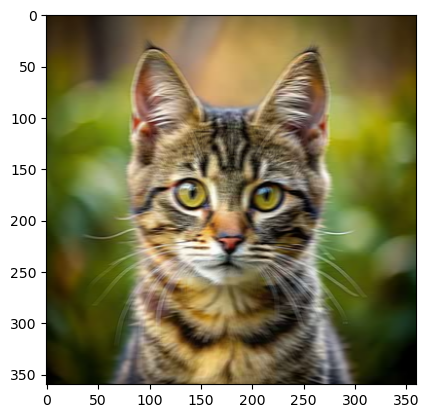

In [18]:
size= 5
motion_blur = np.zeros((size, size))
motion_blur[int((size-1)/2), :] = np.ones(size)
motion_blur = motion_blur / size

#print(motion_blur)
dst = cv2.filter2D(img, -1, motion_blur)
plt.imshow(dst)

## < Sharpening >

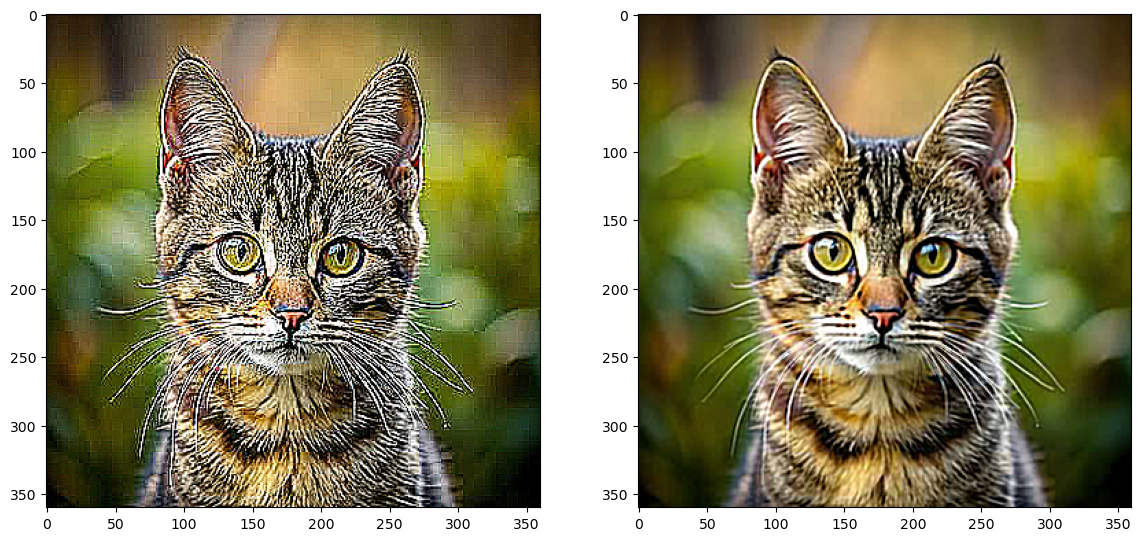

In [19]:
sharpening_1 = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
sharpening_2 = np.array([[-1, -1, -1, -1, -1],
                         [-1, 2, 2, 2, -1],
                         [-1, 2, 9, 2, -1],
                         [-1, 2, 2, 2, -1],
                         [-1, -1, -1, -1, -1]]) / 9.0
#sharpening 주변 값을 어느정도는 사용한다 -> Noise 가 안생기게 된다.
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize= (14,8))
dst1 = cv2.filter2D(img, -1, sharpening_1)
ax1.imshow(dst1)

dst2 = cv2.filter2D(img, -1, sharpening_2)
ax2.imshow(dst2)